In [7]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import os
import sklearn
import time
import string

from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import adjusted_mutual_info_score as AMI
from matplotlib.patches import Patch
from pathlib import Path
from scipy import io
from helps import *
pd.set_option("display.precision", 12)
palette={alg : colors_to_use_pastel[i] for i,alg in enumerate(["ShareTopic","Mowgli","bionSBM"])}

# Figure 1

In [6]:
dfs={}
for dataset in ["PBMC","MouseSkin","BMMCMultiOme","HSPC"]:
    file=f"Datasets/{dataset}/SBM/25Runs_{dataset}_SBMs_Topics_Peak_NMI.tsv.gz"
    if os.path.isfile(file):
        dfs[dataset]=pd.read_csv(file, sep="\t", index_col=0)
        dfs[dataset]=(dfs[dataset]/25).T
for dataset in ["BMMCCite","Spleen"]:
    file=f"Datasets/{dataset}/SBM/25Runs_{dataset}_SBMs_Topics_ADT_NMI.tsv.gz"
    if os.path.isfile(file):
        dfs[dataset]=pd.read_csv(file, sep="\t", index_col=0)
        dfs[dataset]=(dfs[dataset]/25).T

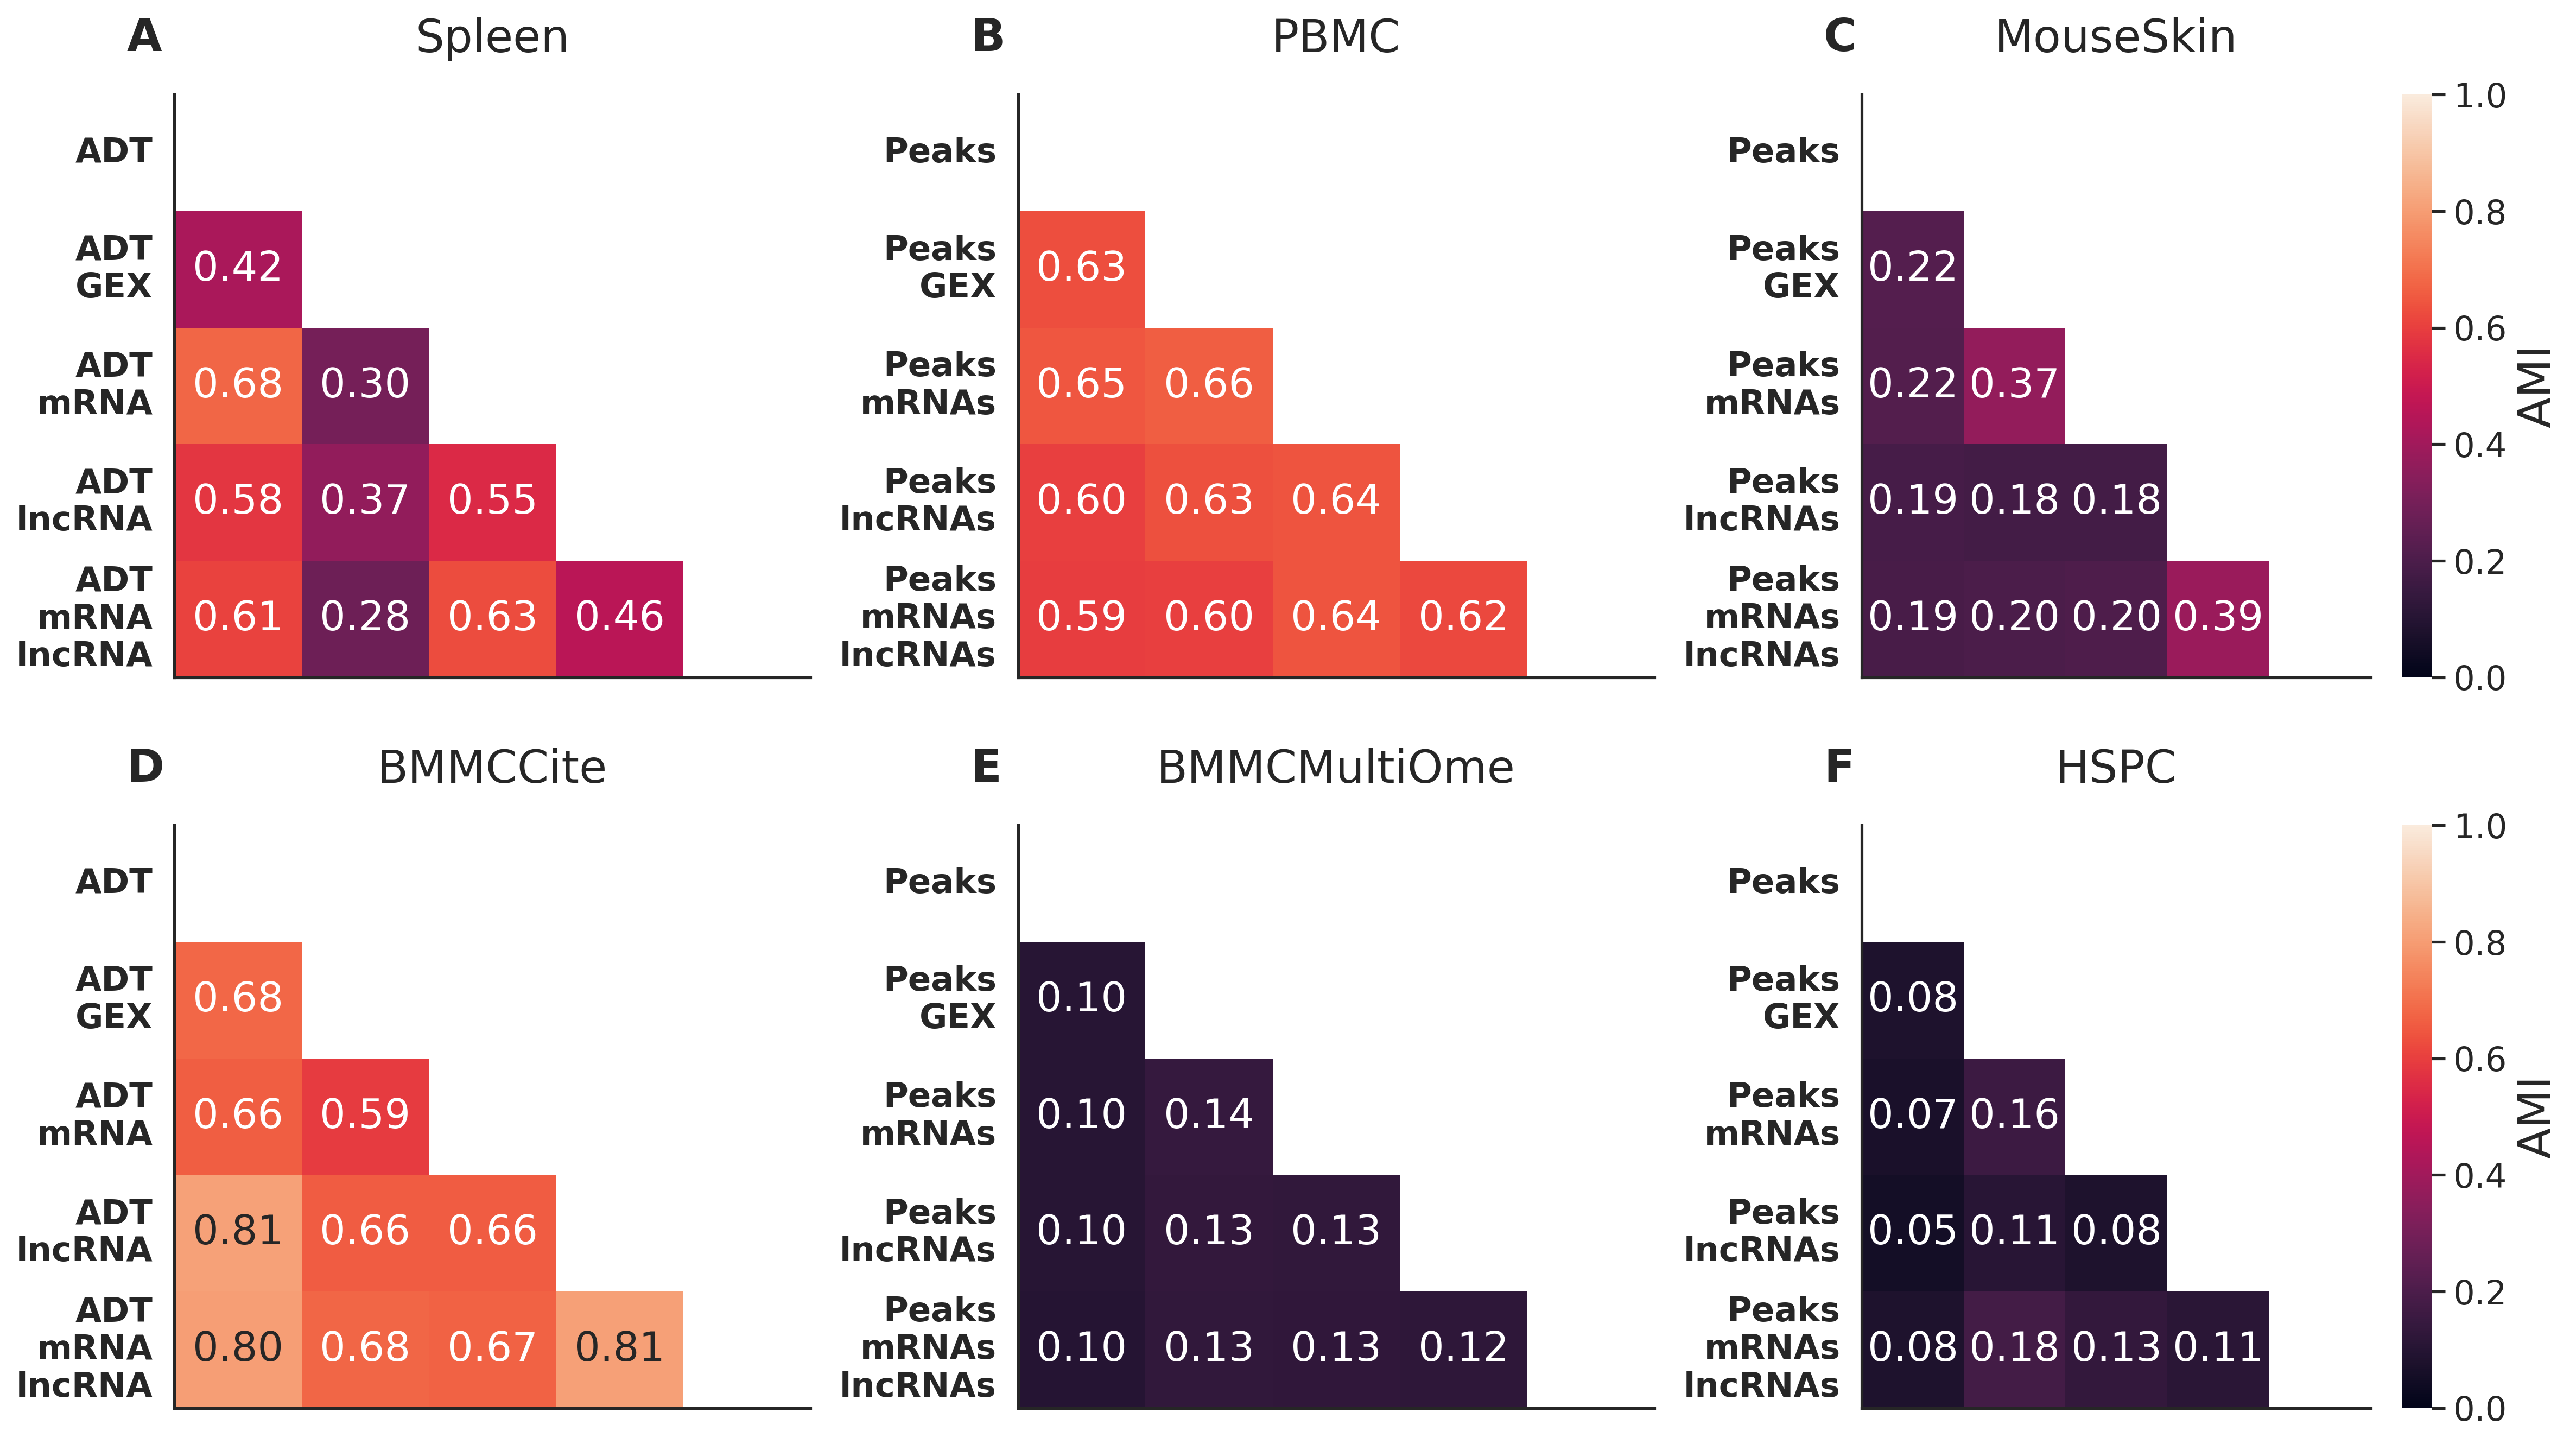

In [8]:
sns.set(style="ticks")
sns.set_style("white")

params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 15,
         'ytick.labelsize': 15,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 9]}
plt.rcParams.update(params)
fig, axs = plt.subplots(2,3)
axs=axs.flatten()

for l, dataset in enumerate(["Spleen","PBMC","MouseSkin", "BMMCCite", "BMMCMultiOme","HSPC"]):
    bar=True if l in [2,5] else False
    if dataset in ["BMMCCite", "Spleen"]:
        order=["ADT", "ADT+GEX", "ADT+mRNA", "ADT+lncRNA", "ADT+mRNA+lncRNA"]
    else:
        order=["Peaks", "Peaks+GEX", "Peaks+mRNAs", "Peaks+lncRNAs", "Peaks+mRNAs+lncRNAs"]
    sns.heatmap(dfs[dataset], annot=True, cbar_kws={"label" : "AMI"}, annot_kws={"size": 18},  ax=axs[l], cbar=bar, vmin=0, vmax=1, fmt='.2f')
    yticks=["\n".join(a.split("+")) for a in order]
    axs[l].set_yticks(axs[l].get_yticks(), yticks, fontweight='bold')
    axs[l].set_title(dataset, y=1.05)
    axs[l].set_xticks([])
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].text(-0.075, 1.075, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  

fig.tight_layout(h_pad=2)
plt.savefig(f"Figures/Figure1.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# Fig 3

In [ ]:
os.system("python SpecDist.py")

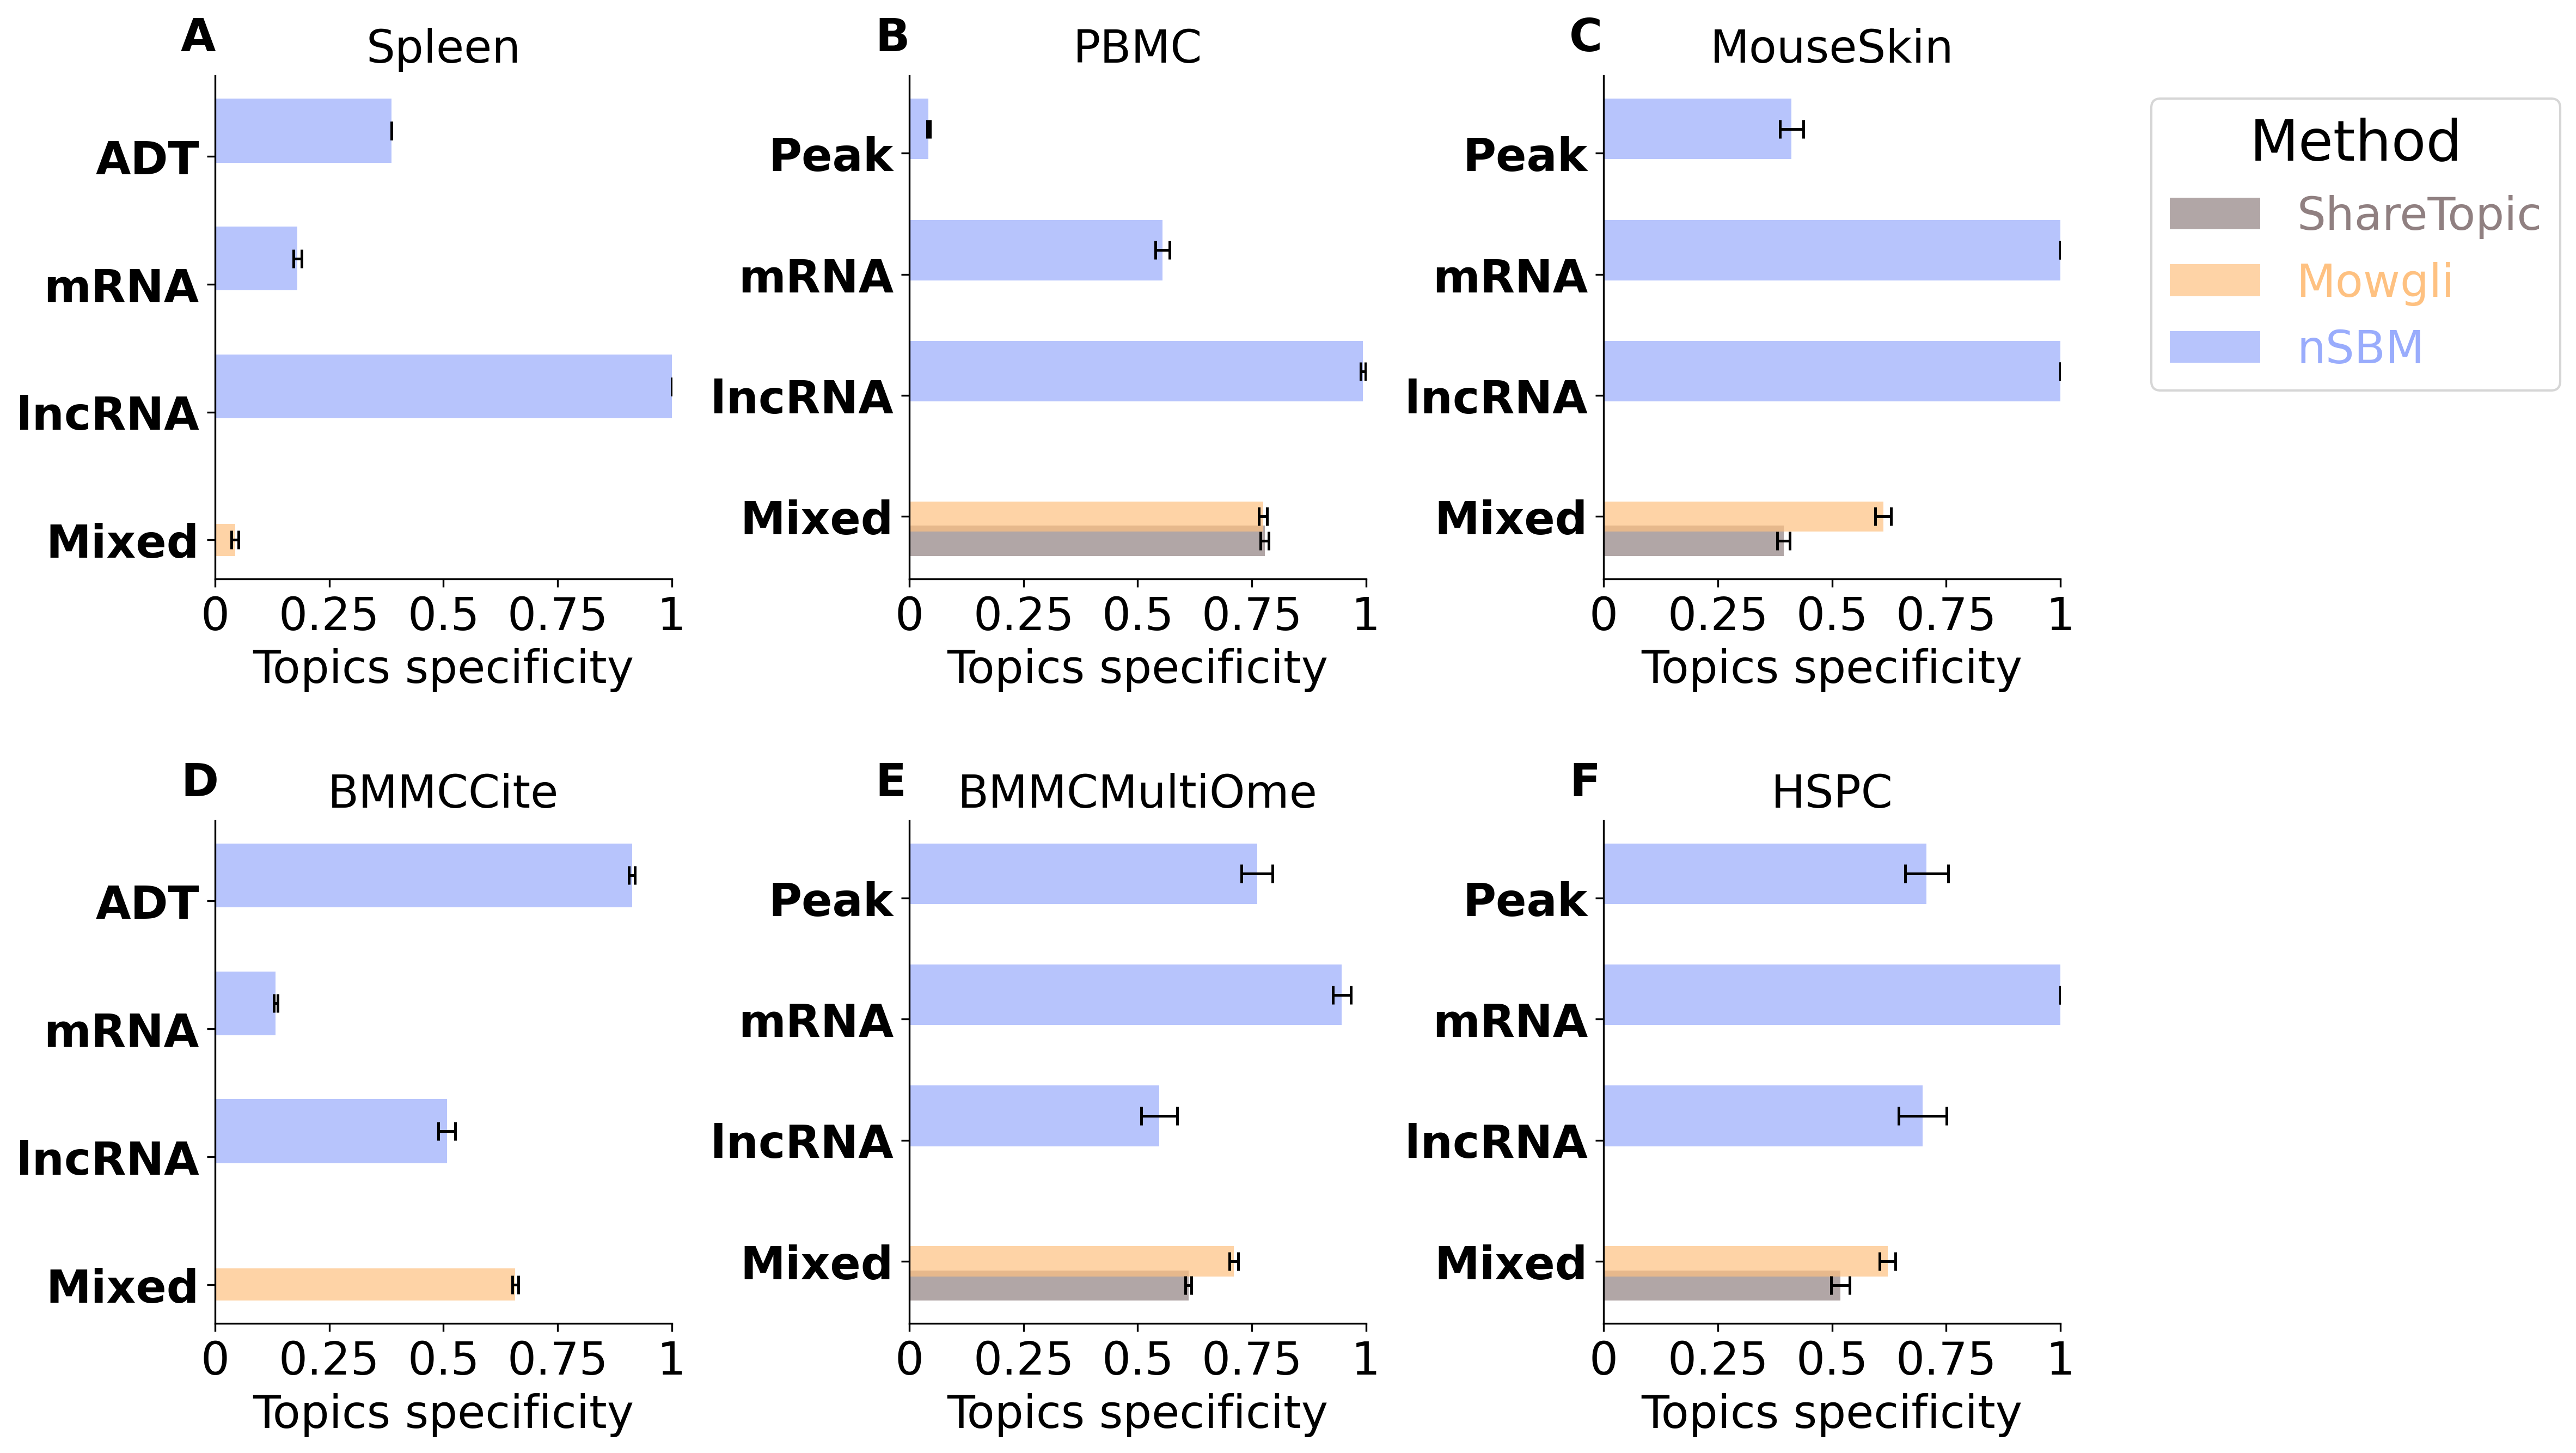

In [6]:
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 20,
         'ytick.labelsize': 20,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 9]}
plt.rcParams.update(params)
fig, axs = plt.subplots(2,3)
axs=axs.flatten()


for l, dataset in enumerate(["Spleen","PBMC","MouseSkin", "BMMCCite", "BMMCMultiOme","HSPC"]):
    df = create_results_topics(dataset,exps=["bionSBM_Peak_mRNA_lncRNA","Mowgli_Peak_mRNA_lncRNA","ShareTopic_Peak_mRNA",
            "ShareTopic_Peak_lncRNA","bionSBM_ADT_mRNA_lncRNA","Mowgli_ADT_mRNA_lncRNA"]).replace({"_" : "+"}, regex=True)
    
    df["Specificty"] = df["DifferentTopics"] / (df["NumberOfCt"] * df["NumberOfTopics"])
    df["Specificty"] = (df["Specificty"] - df["Specificty"].min()) / (df["Specificty"].max() - df["Specificty"].min())

    if dataset in ["BMMCCite", "Spleen"]:
        order = ["ADT", "mRNA", "lncRNA", "Mixed"][::-1]
    else:
        order = ["Peak", "mRNA", "lncRNA", "Mixed"][::-1]

    for i, meth in enumerate(palette.keys()):
        d = df[df["Algorithm"] == meth]

        means = d.groupby("FS")["Specificty"].mean()
        sems  = 3*d.groupby("FS")["Specificty"].sem()

        fs_present = [o for o in order if o in means.index]
        y_positions = np.array([order.index(o) for o in fs_present], dtype=float)
        offset = (i - (len(palette) - 1) / 2) * 0.2
        y_positions += offset

        # Horizontal bar
        height = 0.5 if meth == "bionSBM" else 0.25
        axs[l].barh(y_positions, means[fs_present], height=height,color=palette[meth], alpha=0.7, label=meth)

        # Error bars aligned with the bar
        axs[l].errorbar(x=means[fs_present],y=y_positions,xerr=sems[fs_present],fmt='none',
            ecolor='black',elinewidth=1.2,capsize=4,capthick=1.2)
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_title(dataset)
    axs[l].set_xlim([0, 1])
    axs[l].set_yticks(range(len(order)), range(len(order)), fontweight='bold', fontsize=20)

    axs[l].set_yticklabels(order)
    axs[l].set_xticks([0,0.25, 0.5, 0.75, 1],["0","0.25", "0.5", "0.75", "1"])
    axs[l].set_xlabel("Topics specificity")
    axs[l].text(-0.075, 1.05, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  

handles, labels = axs[2].get_legend_handles_labels()
axs[2].legend(handles, labels,bbox_to_anchor=(1.15, 1), title="Method",fontsize=20,title_fontsize=25, labelcolor=palette.values())
  

fig.tight_layout(h_pad=3)
plt.savefig(f"Figures/Figure3.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# Fig4

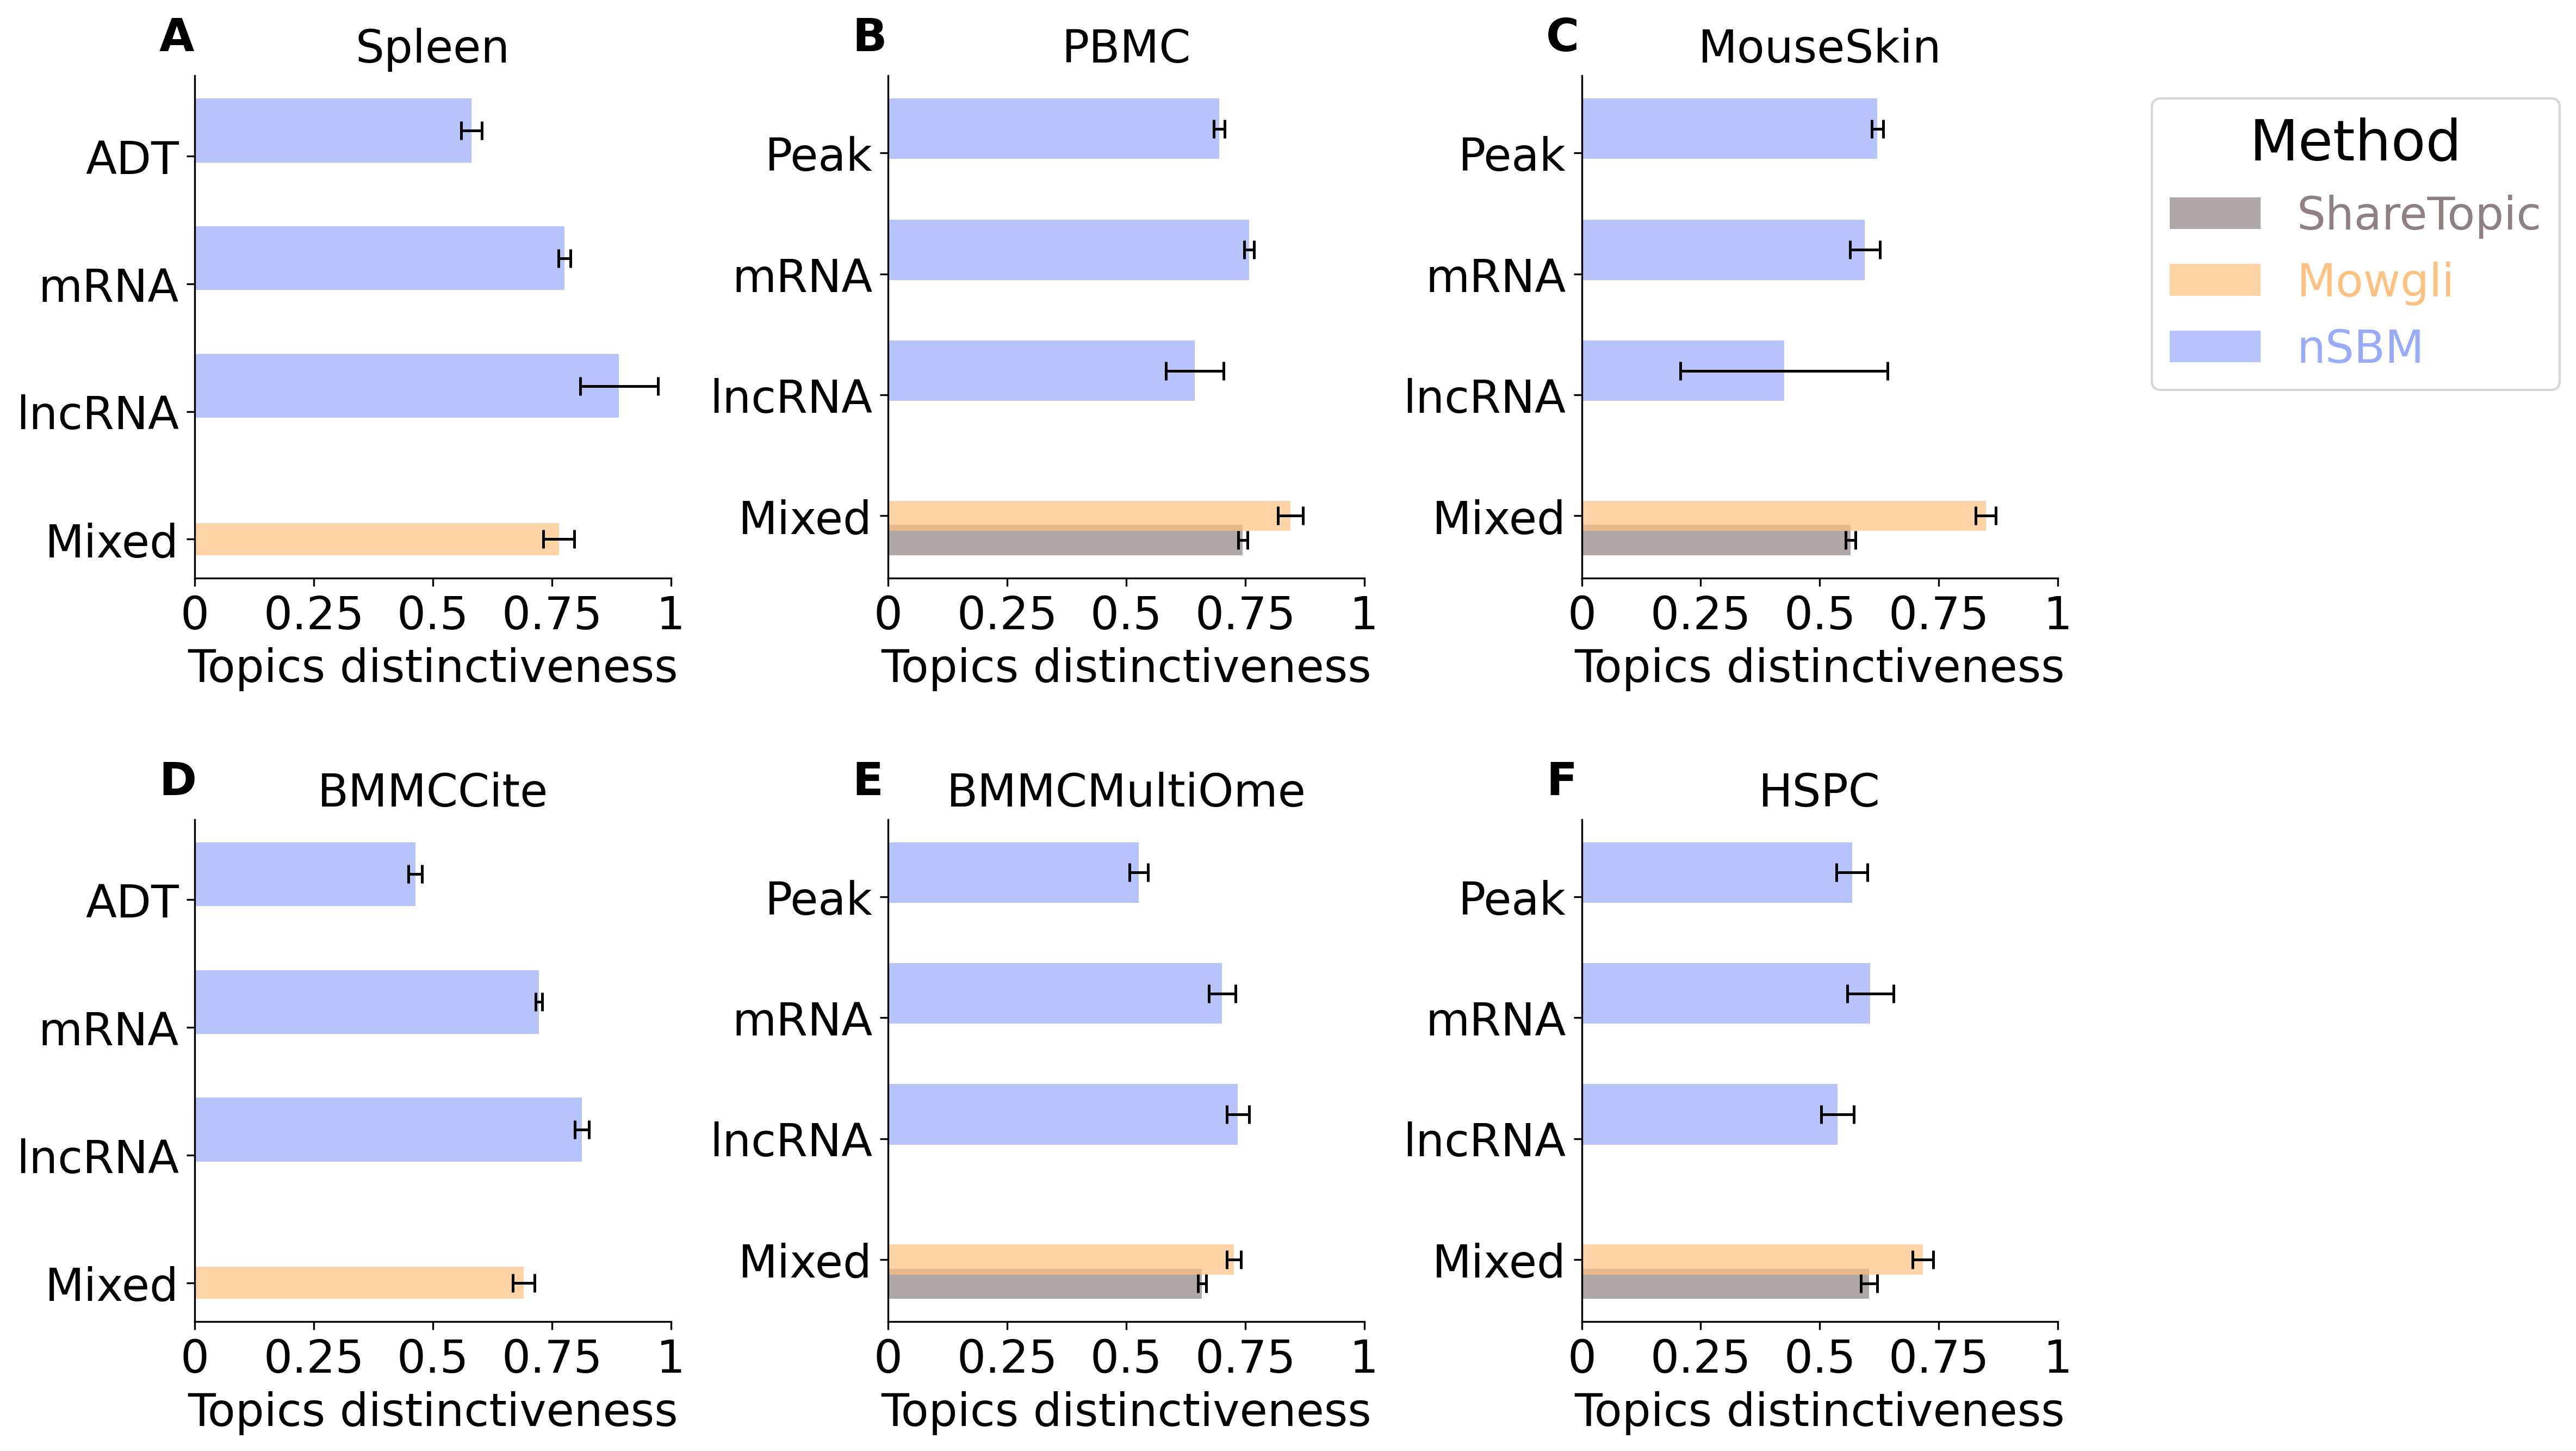

In [7]:
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 20,
         'ytick.labelsize': 20,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 9]}
plt.rcParams.update(params)
fig, axs = plt.subplots(2,3)
axs=axs.flatten()

for l, dataset in enumerate(["Spleen","PBMC","MouseSkin", "BMMCCite", "BMMCMultiOme","HSPC"]):
    df = create_results_topics(
        dataset,
        exps=["bionSBM_Peak_mRNA_lncRNA","Mowgli_Peak_mRNA_lncRNA","ShareTopic_Peak_mRNA",
              "ShareTopic_Peak_lncRNA","bionSBM_ADT_mRNA_lncRNA","Mowgli_ADT_mRNA_lncRNA"]).replace({"_" : "+"}, regex=True)
    df["Topics_distinctiveness"] = (df["Topics_distinctiveness"] - df["Topics_distinctiveness"].min())/(df["Topics_distinctiveness"].max() - df["Topics_distinctiveness"].min())

    if dataset in ["BMMCCite", "Spleen"]:
        order = ["ADT", "mRNA", "lncRNA", "Mixed"][::-1]
    else:
        order = ["Peak", "mRNA", "lncRNA", "Mixed"][::-1]

    for i, meth in enumerate(palette.keys()):
        d = df[df["Algorithm"] == meth]

        means = d.groupby("FS")["Topics_distinctiveness"].mean()
        sems  = 3*d.groupby("FS")["Topics_distinctiveness"].sem()

        fs_present = [o for o in order if o in means.index]
        y_positions = np.array([order.index(o) for o in fs_present], dtype=float)
        offset = (i - (len(palette) - 1) / 2) * 0.2
        y_positions += offset

        # Horizontal bar
        height = 0.5 if meth == "bionSBM" else 0.25
        axs[l].barh(y_positions,means[fs_present],height=height,color=palette[meth],alpha=0.7,label=meth)

        # Error bars aligned with the bar
        axs[l].errorbar(x=means[fs_present],y=y_positions,xerr=sems[fs_present],fmt='none',ecolor='black',elinewidth=1.2,capsize=4,capthick=1.2)
        
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_title(dataset)
    axs[l].set_xlim([0, 1])
    axs[l].set_yticks(range(len(order)))
    axs[l].set_yticklabels(order)
    axs[l].set_xticks([0,0.25, 0.5, 0.75, 1],["0","0.25", "0.5", "0.75", "1"])
    axs[l].text(-0.075, 1.05, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)

handles, labels = axs[2].get_legend_handles_labels()
axs[2].legend(handles, labels,bbox_to_anchor=(1.15, 1), title="Method",fontsize=20,title_fontsize=25, labelcolor=palette.values())

for ax in axs:
    ax.set_xlabel("Topics distinctiveness")

fig.tight_layout(h_pad=3)
plt.savefig(f"Figures/Figure4.png", format="png", dpi=300, bbox_inches='tight')
plt.show()